# Assignment 2: Housing Price Prediction


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

In [29]:
df = pd.read_csv("Housing.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [31]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [32]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [33]:
print("Categorical columns (features mein include nahi kiye):")
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print(categorical_cols)

Categorical columns (features mein include nahi kiye):
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


C:\Users\ASIF\AppData\Local\Temp\ipykernel_8396\2151197146.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


In [34]:
numeric_df = df.select_dtypes(include=[np.number])

print("Numeric columns:", numeric_df.columns.tolist())

Numeric columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [35]:
target = "price"

features = [col for col in numeric_df.columns if col != target]

print("Features:", features)
print("Target:", target)

Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Target: price


In [36]:
X = numeric_df[features]   # Independent variables
y = numeric_df[target]      # Dependent variable 

X.head()

,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2


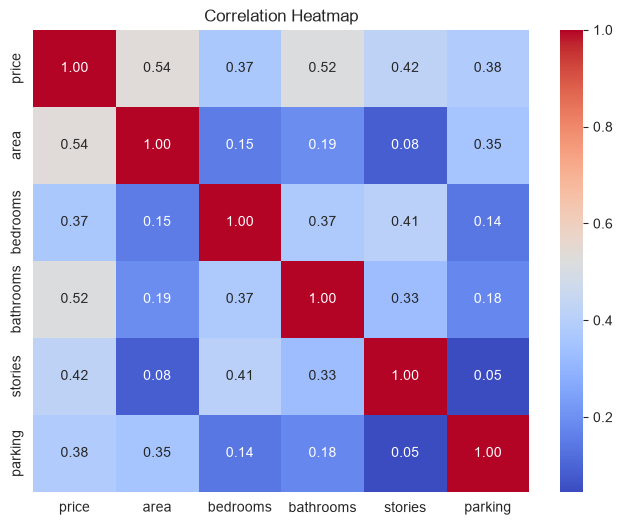

In [37]:
plt.figure(figsize=(8, 6))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [38]:
corr["price"].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

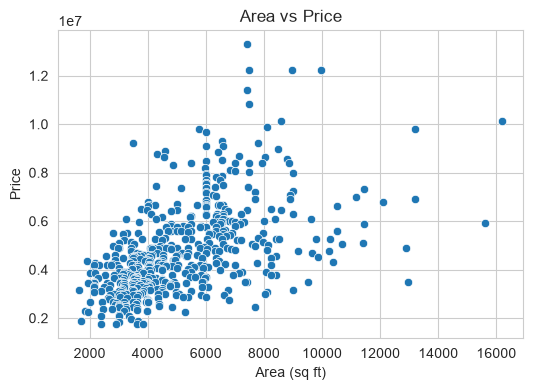

In [39]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="area", y="price", data=df)
plt.title("Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.show()

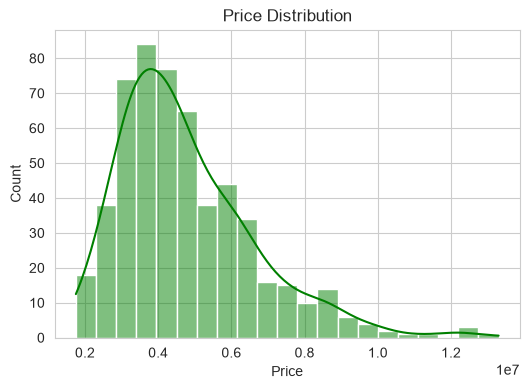

In [40]:
plt.figure(figsize=(6,4))
sns.histplot(df["price"], kde=True, color="green")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (436, 5)
Testing set size: (109, 5)


In [42]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [43]:
coeff_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Intercept:", model.intercept_)
coeff_df

Intercept: 51999.67680883687


,Feature,Coefficient
2,bathrooms,1.185732e+06
3,stories,4.951008e+05
4,parking,3.376608e+05
1,bedrooms,1.512468e+05
0,area,3.088670e+02


In [44]:
y_pred = model.predict(X_test)

results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results_df["Difference"] = results_df["Actual"] - results_df["Predicted"]
results_df.head(10)

,Actual,Predicted,Difference
0,4060000,6.178628e+06,-2.118628e+06
1,6650000,6.370141e+06,2.798591e+05
2,3710000,3.283148e+06,4.268518e+05
3,6440000,4.226008e+06,2.213992e+06
4,2800000,3.409686e+06,-6.096856e+05
5,4900000,4.262158e+06,6.378417e+05
6,5250000,5.493441e+06,-2.434405e+05
7,4543000,5.559898e+06,-1.016898e+06
8,2450000,3.373715e+06,-9.237154e+05
9,3353000,3.020513e+06,3.324868e+05


In [45]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-" * 30)
print(f"Mean Absolute Error (MAE):  {mae:.2f}")
print(f"Mean Squared Error (MSE):   {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Results
------------------------------
Mean Absolute Error (MAE):  1127483.35
Mean Squared Error (MSE):   2292721545725.36
Root Mean Squared Error (RMSE): 1514173.55
R² Score: 0.5464


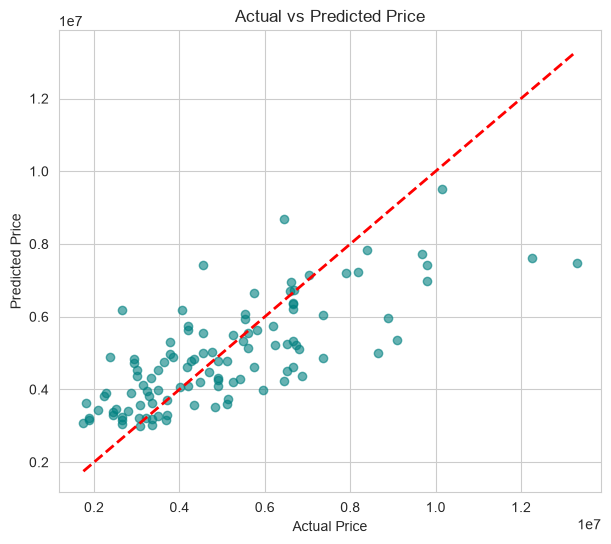

In [46]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

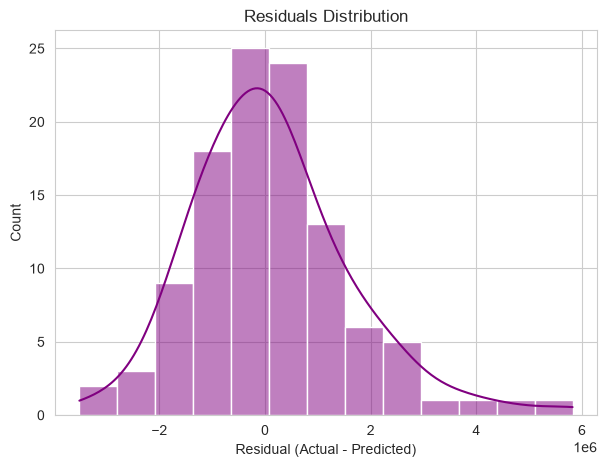

In [47]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, color="purple")
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()